# Two-segment cantilever beam vibration (Timoshenko, 1D)

This example follows the repository's *example-problem* layout. It generates full-order mode-shape snapshots by solving a generalized eigenproblem and then runs a POD-ROM on the first mode shape.


## Environment setup


### Directory

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


### Standard Imports

In [2]:
# Standard imports used across examples
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.rom.rom_error_est import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.masterclass as master
# Register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")


PETSc available: True


### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();
import sci_mplstyle_package

In [4]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full-order snapshot generation


In [5]:
# Conditional execution block for simulation data generation
if generate_data:
    
    sim = master.fom_simulation(num_snapshots=2**4)
    sim.run_simulation()

Snap 1/32 params=[0.02732932 0.0167783 ]
Snap 2/32 params=[0.01179344 0.021704  ]
Snap 3/32 params=[0.01631304 0.01074593]
Snap 4/32 params=[0.02218109 0.02582055]
Snap 5/32 params=[0.02258946 0.01327178]
Snap 6/32 params=[0.01828166 0.02835342]
Snap 7/32 params=[0.01345554 0.01927233]
Snap 8/32 params=[0.02805647 0.0241904 ]
Snap 9/32 params=[0.02937007 0.0121961 ]
Snap 10/32 params=[0.01474964 0.02742696]
Snap 11/32 params=[0.01960508 0.0152598 ]
Snap 12/32 params=[0.02389331 0.02002922]
Snap 13/32 params=[0.02086739 0.01775391]
Snap 14/32 params=[0.01501899 0.0225157 ]
Snap 15/32 params=[0.01047011 0.01472186]
Snap 16/32 params=[0.0260254  0.02995974]
Snap 17/32 params=[0.01057812 0.02556039]
Snap 18/32 params=[0.0256555  0.01087965]
Snap 19/32 params=[0.02090269 0.02462096]
Snap 20/32 params=[0.01535415 0.01932001]
Snap 21/32 params=[0.01758516 0.02097793]
Snap 22/32 params=[0.02359943 0.0150715 ]
Snap 23/32 params=[0.02859268 0.02879326]
Snap 24/32 params=[0.01273226 0.01475707]
S

### Load Simulation data

In [6]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_eigenVP\ROM_data


### Generate Training Solution Dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list =  np.asarray(rom_data.param_list)

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap = len(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


32


### Mean Subtraction

In [8]:
LS_train.shape

(16, 51202)

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.zeros_like(LS_train[0]) #np.mean(LS_train,axis = 0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Performing SVD on solution snapshots

Number of modes selected: 3


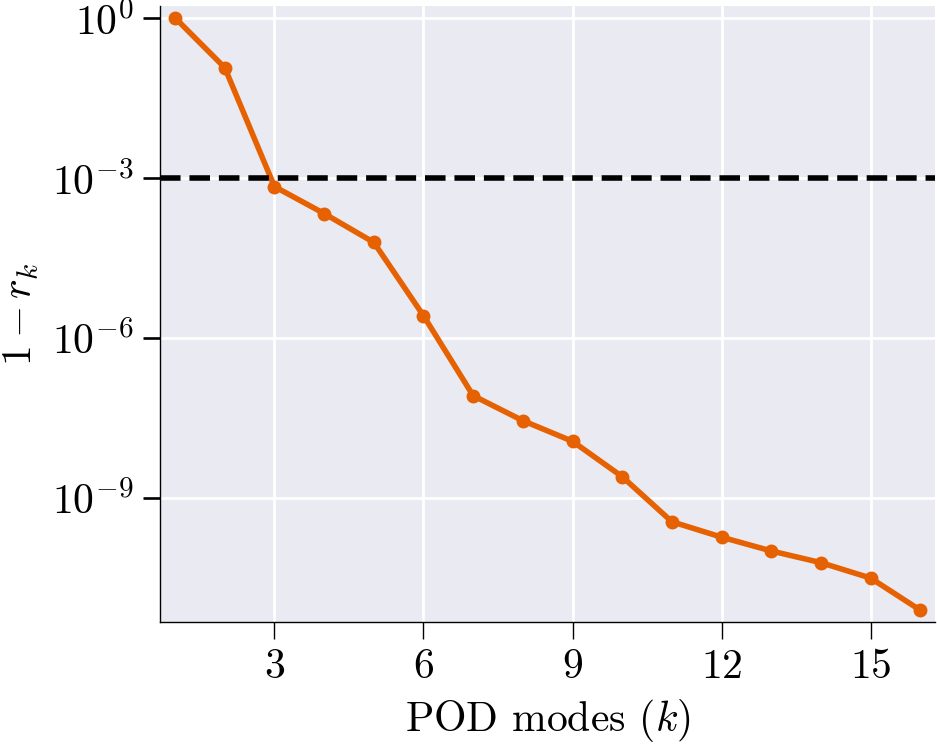

In [10]:
if run_svd:
    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0

    n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-3, modes=True)
    V_sel = U[:, :n_sel]
    plt.ylabel('$1-r_{k}$')
    plt.xlabel('POD modes ($k$)')

In [11]:
V_sel.shape

(51202, 3)

## Online ROM evaluation


In [12]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel = V_sel, train_ref= LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_eigenVP\ROM_data


In [13]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/16 params=[0.01057812 0.02556039]
Snap 2/16 params=[0.0256555  0.01087965]
Snap 3/16 params=[0.02090269 0.02462096]
Snap 4/16 params=[0.01535415 0.01932001]
Snap 5/16 params=[0.01758516 0.02097793]
Snap 6/16 params=[0.02359943 0.0150715 ]
Snap 7/16 params=[0.02859268 0.02879326]
Snap 8/16 params=[0.01273226 0.01475707]
Snap 9/16 params=[0.01434368 0.02258255]
Snap 10/16 params=[0.02942285 0.01854501]
Snap 11/16 params=[0.02464442 0.02726799]
Snap 12/16 params=[0.01909889 0.01136047]
Snap 13/16 params=[0.01639898 0.028332  ]
Snap 14/16 params=[0.02241627 0.01302992]
Snap 15/16 params=[0.02726676 0.02177245]
Snap 16/16 params=[0.01140814 0.01709039]


In [14]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up#[1:]
    ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

ROM Accuracy Report

Global Errors:
L2 Error:                 4.6445e-02
Relative L2 Error:        9.6514e-04
L∞ Error:                 4.0819e-03
Relative L∞ Error:        1.9863e-03
RMSE:                     8.2102e-04
MAE:                      5.1835e-04

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0003

Error Distribution:
Median Error:             1.7330e-05
95th Percentile Error:    1.9967e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 5.1950e-05
Max Rel L2 Error over time/parameter: 1.1205e-04
Min Rel L2 Error over time/parameter: 8.7637e-06
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

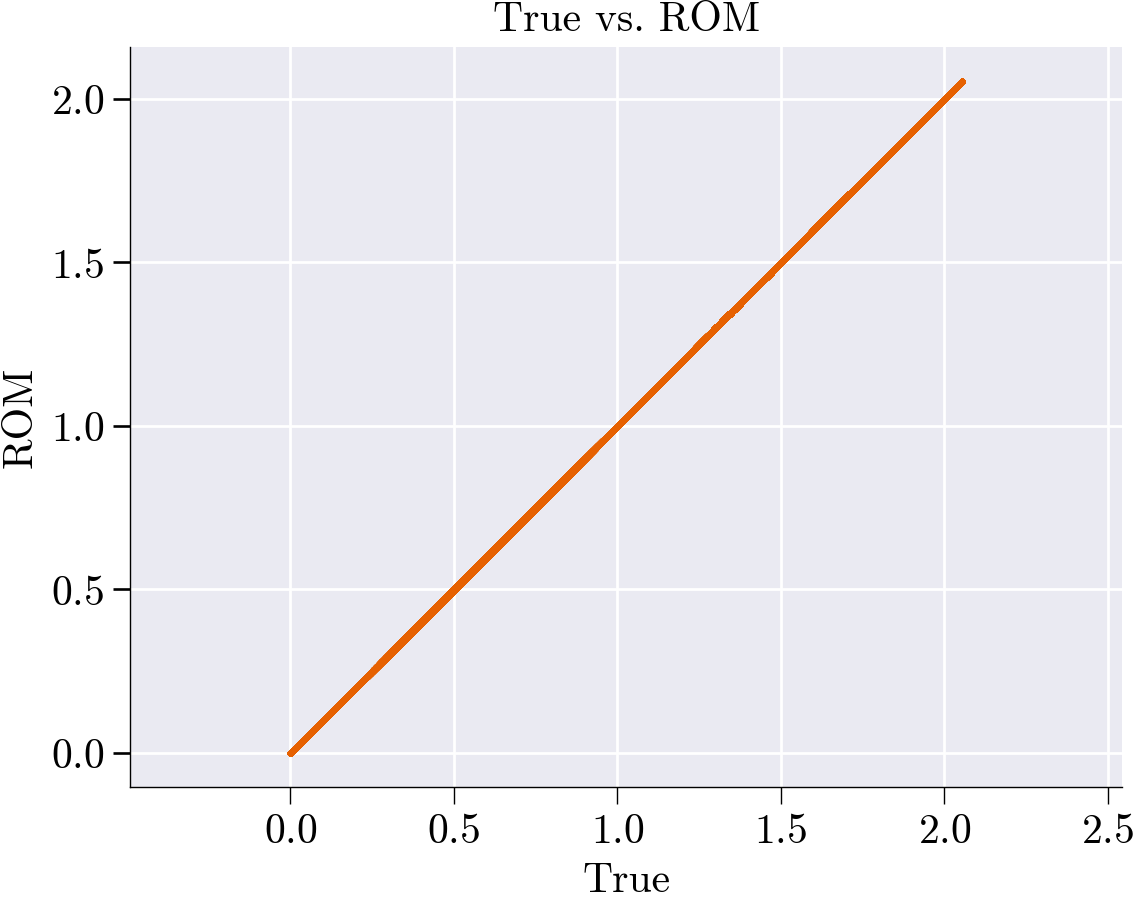

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


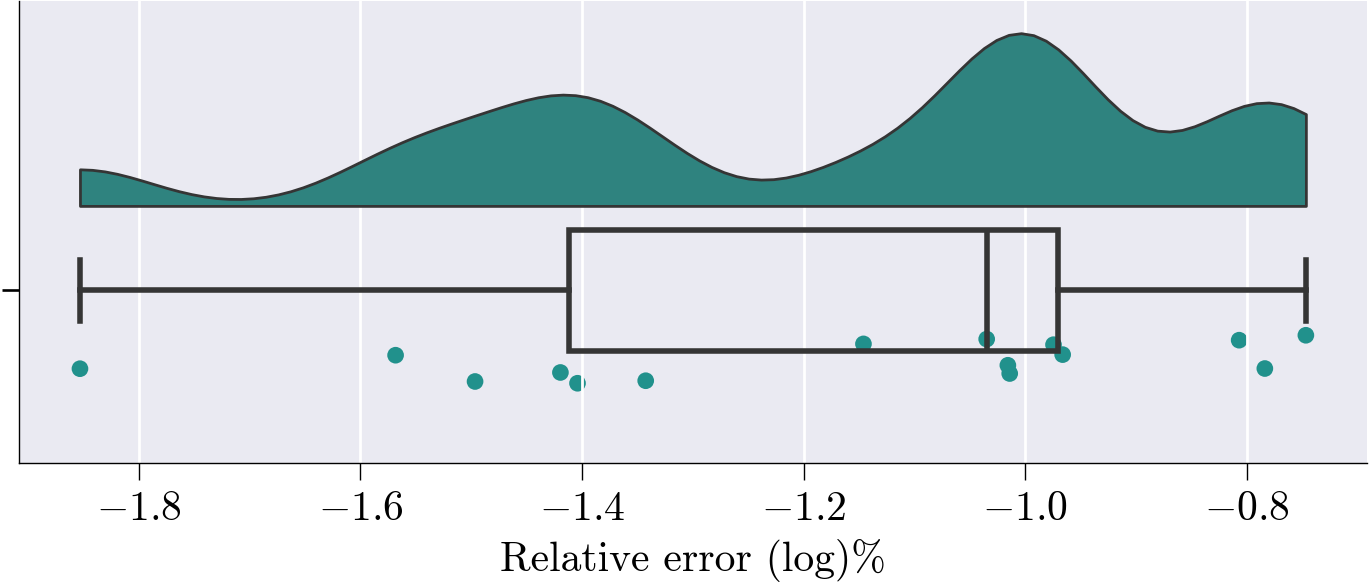

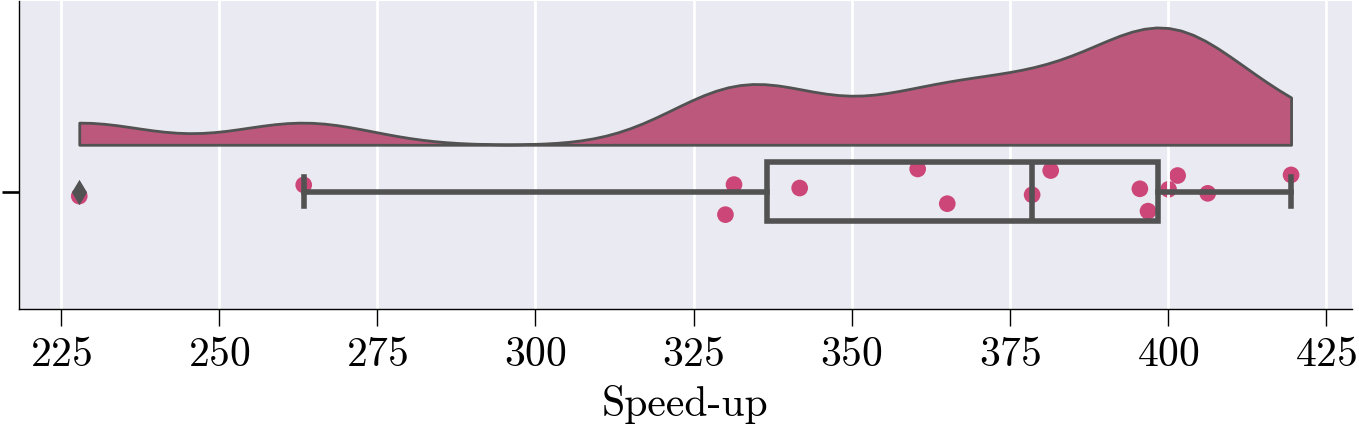

In [15]:
if rom_report:
    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)
    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)
    
    plot_rom_error_diagnostics_flat(
        LS_test[1:],
        LS_rom[1:],
        ROM_relative_error[1:],          # (p,)
        ROM_speed_up[1:], # (p,)
        sim_axis=['True', 'ROM'],
        metrics=matrix
    )